# Dollar-Volume Sampling for Tick Data

This notebook demonstrates efficient methods for computing dollar-volume bars from tick data using various tools and libraries.

## Table of Contents
1. Setup and Installation
2. Generate Sample Tick Data
3. Implementation with Polars (Fastest)
4. Implementation with DuckDB (SQL-based)
5. Implementation with Pandas (Traditional)
6. Implementation with Numba (Custom High-Performance)
7. Performance Comparison
8. Real-world Example with Binance Data
9. Storage with ArcticDB

## 1. Setup and Installation

Install required libraries:

In [1]:
# Install required libraries
# !pip install polars duckdb pandas numpy numba matplotlib seaborn arcticdb

In [2]:
import numpy as np
import pandas as pd
import polars as pl
import duckdb
from numba import jit
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import time
from typing import Tuple, List, Dict
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Generate Sample Tick Data

Let's create realistic sample tick data for testing:

In [3]:
def generate_tick_data(n_ticks: int = 100000, seed: int = 42) -> pd.DataFrame:
    """
    Generate synthetic tick data with realistic properties.
    
    Args:
        n_ticks: Number of ticks to generate
        seed: Random seed for reproducibility
    
    Returns:
        DataFrame with timestamp, price, and volume columns
    """
    np.random.seed(seed)
    
    # Generate timestamps (1 second intervals with some randomness)
    start_time = datetime(2024, 1, 1, 9, 0, 0)
    time_deltas = np.random.exponential(1, n_ticks).cumsum()
    timestamps = [start_time + timedelta(seconds=td) for td in time_deltas]
    
    # Generate prices (random walk with mean reversion)
    initial_price = 100.0
    returns = np.random.normal(0, 0.001, n_ticks)
    price_mult = np.exp(returns.cumsum())
    prices = initial_price * price_mult
    
    # Generate volumes (log-normal distribution)
    volumes = np.random.lognormal(8, 1.5, n_ticks)
    volumes = np.clip(volumes, 1, 1e6).astype(int)
    
    return pd.DataFrame({
        'timestamp': timestamps,
        'price': prices,
        'volume': volumes
    })

# Generate sample data
tick_data = generate_tick_data(n_ticks=100000)
print(f"Generated {len(tick_data):,} ticks")
print(f"\nFirst few rows:")
print(tick_data.head())
print(f"\nData statistics:")
print(tick_data.describe())

Generated 100,000 ticks

First few rows:
                   timestamp       price  volume
0 2024-01-01 09:00:00.469268  100.084307   66692
1 2024-01-01 09:00:03.479390  100.337227     731
2 2024-01-01 09:00:04.796135  100.327181    1785
3 2024-01-01 09:00:05.709078  100.106943    1680
4 2024-01-01 09:00:05.878703  100.249732    4308

Data statistics:
                           timestamp          price          volume
count                         100000  100000.000000   100000.000000
mean   2024-01-01 22:50:55.152236544     117.122224     9068.923890
min       2024-01-01 09:00:00.469268      99.422899        3.000000
25%       2024-01-01 15:58:31.397920     113.141123     1080.000000
50%    2024-01-01 22:50:06.765496064     117.432189     2969.000000
75%    2024-01-02 05:45:50.918158592     122.701595     8171.000000
max       2024-01-02 12:39:57.015906     131.096909  1000000.000000
std                              NaN       6.595942    23885.800658


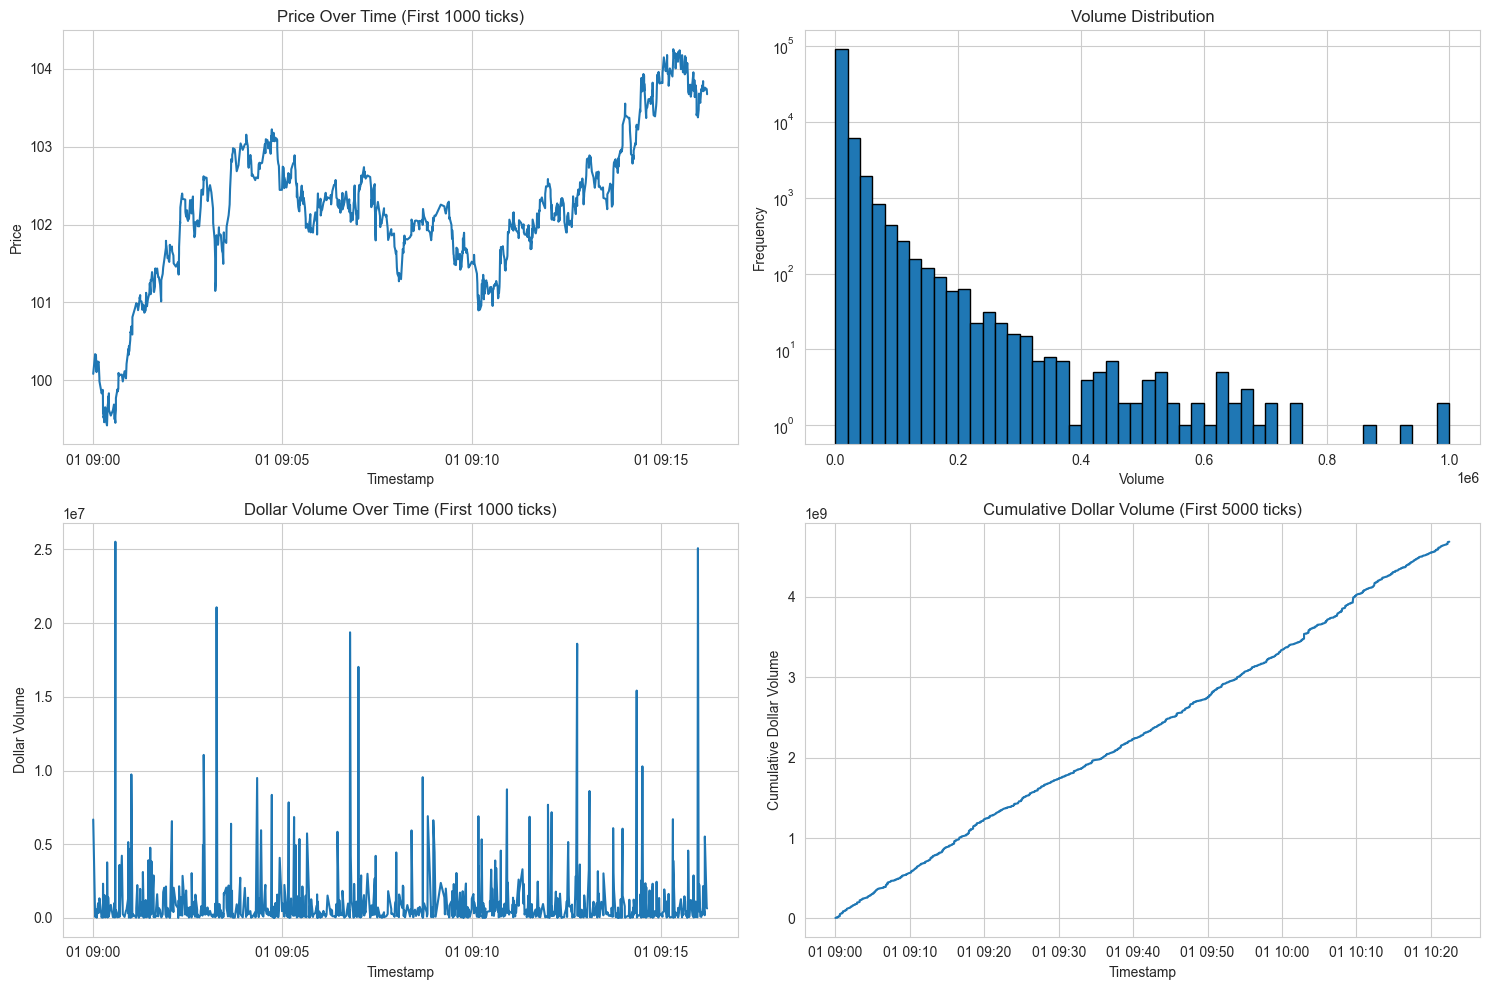

In [4]:
# Visualize the tick data
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Price over time
axes[0, 0].plot(tick_data['timestamp'][:1000], tick_data['price'][:1000])
axes[0, 0].set_title('Price Over Time (First 1000 ticks)')
axes[0, 0].set_xlabel('Timestamp')
axes[0, 0].set_ylabel('Price')

# Volume distribution
axes[0, 1].hist(tick_data['volume'], bins=50, edgecolor='black')
axes[0, 1].set_title('Volume Distribution')
axes[0, 1].set_xlabel('Volume')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_yscale('log')

# Dollar volume over time
dollar_volume = tick_data['price'] * tick_data['volume']
axes[1, 0].plot(tick_data['timestamp'][:1000], dollar_volume[:1000])
axes[1, 0].set_title('Dollar Volume Over Time (First 1000 ticks)')
axes[1, 0].set_xlabel('Timestamp')
axes[1, 0].set_ylabel('Dollar Volume')

# Cumulative dollar volume
cum_dollar_volume = dollar_volume.cumsum()
axes[1, 1].plot(tick_data['timestamp'][:5000], cum_dollar_volume[:5000])
axes[1, 1].set_title('Cumulative Dollar Volume (First 5000 ticks)')
axes[1, 1].set_xlabel('Timestamp')
axes[1, 1].set_ylabel('Cumulative Dollar Volume')

plt.tight_layout()
plt.show()

## 3. Implementation with Polars (Fastest)

Polars is typically 10-50x faster than pandas for this type of operation:

In [5]:
def create_dollar_bars_polars(df: pl.DataFrame, dollar_threshold: float) -> pl.DataFrame:
    """
    Create dollar bars from tick data using Polars.
    
    Args:
        df: Polars DataFrame with columns ['timestamp', 'price', 'volume']
        dollar_threshold: Dollar volume threshold for each bar
    
    Returns:
        DataFrame with OHLCV dollar bars
    """
    # Calculate dollar volume for each tick
    df = df.with_columns(
        (pl.col('price') * pl.col('volume')).alias('dollar_volume')
    )
    
    # Calculate cumulative dollar volume (use cum_sum instead of cumsum)
    df = df.with_columns(
        pl.col('dollar_volume').cum_sum().alias('cum_dollar_volume')
    )
    
    # Identify bar boundaries (when threshold is exceeded)
    df = df.with_columns(
        (pl.col('cum_dollar_volume') // dollar_threshold).alias('bar_id')
    )
    
    # Aggregate to create bars
    dollar_bars = df.group_by('bar_id').agg([
        pl.col('timestamp').first().alias('timestamp'),
        pl.col('price').first().alias('open'),
        pl.col('price').max().alias('high'),
        pl.col('price').min().alias('low'),
        pl.col('price').last().alias('close'),
        pl.col('volume').sum().alias('volume'),
        pl.col('dollar_volume').sum().alias('dollar_volume'),
        pl.len().alias('tick_count'),
        pl.col('price').std().alias('price_std'),
        (pl.col('price').last() - pl.col('price').first()).alias('price_change')
    ]).sort('bar_id')
    
    return dollar_bars

# Convert to Polars and create dollar bars
tick_data_pl = pl.from_pandas(tick_data)

# Calculate appropriate threshold (average dollar volume per tick * desired ticks per bar)
avg_dollar_volume = (tick_data['price'] * tick_data['volume']).mean()
desired_ticks_per_bar = 100
dollar_threshold = avg_dollar_volume * desired_ticks_per_bar

print(f"Using dollar threshold: ${dollar_threshold:,.2f}")

# Create dollar bars
start_time = time.time()
dollar_bars_pl = create_dollar_bars_polars(tick_data_pl, dollar_threshold)
polars_time = time.time() - start_time

print(f"\nCreated {len(dollar_bars_pl)} dollar bars in {polars_time:.3f} seconds")
print(f"\nFirst few dollar bars:")
print(dollar_bars_pl.head())

Using dollar threshold: $106,224,276.56

Created 1001 dollar bars in 0.003 seconds

First few dollar bars:
shape: (5, 11)
┌────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ bar_id ┆ timestamp  ┆ open       ┆ high      ┆ … ┆ dollar_vo ┆ tick_coun ┆ price_std ┆ price_cha │
│ ---    ┆ ---        ┆ ---        ┆ ---       ┆   ┆ lume      ┆ t         ┆ ---       ┆ nge       │
│ f64    ┆ datetime[n ┆ f64        ┆ f64       ┆   ┆ ---       ┆ ---       ┆ f64       ┆ ---       │
│        ┆ s]         ┆            ┆           ┆   ┆ f64       ┆ u32       ┆           ┆ f64       │
╞════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0.0    ┆ 2024-01-01 ┆ 100.084307 ┆ 101.12424 ┆ … ┆ 1.0269e8  ┆ 93        ┆ 0.551534  ┆ 0.958212  │
│        ┆ 09:00:00.4 ┆            ┆ 2         ┆   ┆           ┆           ┆           ┆           │
│        ┆ 69268      ┆            ┆           ┆   ┆           ┆      

## 4. Implementation with DuckDB (SQL-based)

DuckDB provides a SQL interface for those comfortable with SQL:

In [6]:
def create_dollar_bars_duckdb(df: pd.DataFrame, dollar_threshold: float) -> pd.DataFrame:
    """
    Create dollar bars using DuckDB SQL.
    
    Args:
        df: Pandas DataFrame with tick data
        dollar_threshold: Dollar volume threshold for each bar
    
    Returns:
        DataFrame with dollar bars
    """
    conn = duckdb.connect(':memory:')
    
    # Register the DataFrame
    conn.register('ticks', df)
    
    query = f"""
    WITH tick_data AS (
        SELECT 
            timestamp,
            price,
            volume,
            price * volume as dollar_volume
        FROM ticks
    ),
    cumulative AS (
        SELECT 
            *,
            SUM(dollar_volume) OVER (ORDER BY timestamp) as cum_dollar_volume,
            FLOOR(SUM(dollar_volume) OVER (ORDER BY timestamp) / {dollar_threshold}) as bar_id
        FROM tick_data
    )
    SELECT 
        bar_id,
        MIN(timestamp) as timestamp,
        FIRST(price) as open,
        MAX(price) as high,
        MIN(price) as low,
        LAST(price) as close,
        SUM(volume) as volume,
        SUM(dollar_volume) as dollar_volume,
        COUNT(*) as tick_count,
        STDDEV(price) as price_std,
        LAST(price) - FIRST(price) as price_change
    FROM cumulative
    GROUP BY bar_id
    ORDER BY bar_id
    """
    
    result = conn.execute(query).df()
    conn.close()
    
    return result

# Create dollar bars with DuckDB
start_time = time.time()
dollar_bars_duck = create_dollar_bars_duckdb(tick_data, dollar_threshold)
duckdb_time = time.time() - start_time

print(f"Created {len(dollar_bars_duck)} dollar bars in {duckdb_time:.3f} seconds")
print(f"\nFirst few dollar bars:")
print(dollar_bars_duck.head())

Created 1000 dollar bars in 0.023 seconds

First few dollar bars:
   bar_id                  timestamp        open        high         low  \
0     0.0 2024-01-01 09:00:00.469268  100.084307  101.124242   99.422899   
1     1.0 2024-01-01 09:01:27.882691  101.071425  102.619107  101.013991   
2     2.0 2024-01-01 09:03:15.791004  101.863142  103.221258  101.495478   
3     3.0 2024-01-01 09:05:09.974405  102.591476  102.888431  101.872300   
4     4.0 2024-01-01 09:07:00.287879  102.079647  102.736256  101.271952   

        close     volume  dollar_volume  tick_count  price_std  price_change  
0  101.042519  1026083.0   1.026882e+08          93   0.551534      0.958212  
1  101.837800   996728.0   1.015094e+08         117   0.441548      0.766375  
2  102.660371  1088762.0   1.116372e+08         106   0.455699      0.797229  
3  102.070249  1063732.0   1.088271e+08         116   0.210478     -0.521227  
4  102.033863  1024122.0   1.045072e+08          97   0.319233     -0.045784  


## 5. Implementation with Pandas (Traditional)

Traditional pandas implementation for comparison:

In [7]:
def create_dollar_bars_pandas(df: pd.DataFrame, dollar_threshold: float) -> pd.DataFrame:
    """
    Create dollar bars from tick data using Pandas.
    
    Args:
        df: Pandas DataFrame with columns ['timestamp', 'price', 'volume']
        dollar_threshold: Dollar volume threshold for each bar
    
    Returns:
        DataFrame with OHLCV dollar bars
    """
    # Calculate dollar volume
    df['dollar_volume'] = df['price'] * df['volume']
    
    # Calculate cumulative dollar volume
    df['cum_dollar_volume'] = df['dollar_volume'].cumsum()
    
    # Identify bar boundaries
    df['bar_id'] = (df['cum_dollar_volume'] // dollar_threshold).astype(int)
    
    # Aggregate to create bars
    dollar_bars = df.groupby('bar_id').agg({
        'timestamp': 'first',
        'price': ['first', 'max', 'min', 'last', 'std'],
        'volume': 'sum',
        'dollar_volume': 'sum'
    })
    
    # Flatten column names
    dollar_bars.columns = ['timestamp', 'open', 'high', 'low', 'close', 'price_std', 'volume', 'dollar_volume']
    
    # Add tick count and price change
    tick_counts = df.groupby('bar_id').size()
    dollar_bars['tick_count'] = tick_counts
    dollar_bars['price_change'] = dollar_bars['close'] - dollar_bars['open']
    
    return dollar_bars.reset_index()

# Create dollar bars with Pandas
tick_data_copy = tick_data.copy()  # Make a copy to avoid modifying original
start_time = time.time()
dollar_bars_pd = create_dollar_bars_pandas(tick_data_copy, dollar_threshold)
pandas_time = time.time() - start_time

print(f"Created {len(dollar_bars_pd)} dollar bars in {pandas_time:.3f} seconds")
print(f"\nFirst few dollar bars:")
print(dollar_bars_pd.head())

Created 1001 dollar bars in 0.010 seconds

First few dollar bars:
   bar_id                  timestamp        open        high         low  \
0       0 2024-01-01 09:00:00.469268  100.084307  101.124242   99.422899   
1       1 2024-01-01 09:01:27.882691  101.071425  102.619107  101.013991   
2       2 2024-01-01 09:03:15.791004  101.863142  103.221258  101.495478   
3       3 2024-01-01 09:05:09.974405  102.591476  102.888431  101.872300   
4       4 2024-01-01 09:07:00.287879  102.079647  102.736256  101.271952   

        close  price_std   volume  dollar_volume  tick_count  price_change  
0  101.042519   0.551534  1026083   1.026882e+08          93      0.958212  
1  101.837800   0.441548   996728   1.015094e+08         117      0.766375  
2  102.660371   0.455699  1088762   1.116372e+08         106      0.797229  
3  102.070249   0.210478  1063732   1.088271e+08         116     -0.521227  
4  102.033863   0.319233  1024122   1.045072e+08          97     -0.045784  


## 6. Implementation with Numba (Custom High-Performance)

Numba JIT compilation for maximum performance:

In [8]:
@jit(nopython=True)
def create_dollar_bars_numba_core(prices: np.ndarray, volumes: np.ndarray, threshold: float):
    """
    Core Numba function for creating dollar bars.
    
    Returns:
        Tuple of arrays (bar_indices, opens, highs, lows, closes, volumes, tick_counts)
    """
    n = len(prices)
    
    # Pre-allocate arrays (maximum possible bars)
    max_bars = n
    bar_indices = np.zeros(max_bars, dtype=np.int32)
    opens = np.zeros(max_bars, dtype=np.float64)
    highs = np.zeros(max_bars, dtype=np.float64)
    lows = np.zeros(max_bars, dtype=np.float64)
    closes = np.zeros(max_bars, dtype=np.float64)
    bar_volumes = np.zeros(max_bars, dtype=np.float64)
    tick_counts = np.zeros(max_bars, dtype=np.int32)
    
    bar_count = 0
    cum_dollar_volume = 0.0
    bar_start_idx = 0
    
    for i in range(n):
        dollar_volume = prices[i] * volumes[i]
        cum_dollar_volume += dollar_volume
        
        if cum_dollar_volume >= threshold or i == n - 1:
            # Create bar
            bar_prices = prices[bar_start_idx:i+1]
            bar_vols = volumes[bar_start_idx:i+1]
            
            bar_indices[bar_count] = bar_count
            opens[bar_count] = bar_prices[0]
            highs[bar_count] = np.max(bar_prices)
            lows[bar_count] = np.min(bar_prices)
            closes[bar_count] = bar_prices[-1]
            bar_volumes[bar_count] = np.sum(bar_vols)
            tick_counts[bar_count] = len(bar_prices)
            
            bar_count += 1
            cum_dollar_volume = 0.0
            bar_start_idx = i + 1
    
    # Trim arrays to actual size
    return (
        bar_indices[:bar_count],
        opens[:bar_count],
        highs[:bar_count],
        lows[:bar_count],
        closes[:bar_count],
        bar_volumes[:bar_count],
        tick_counts[:bar_count]
    )

def create_dollar_bars_numba(df: pd.DataFrame, dollar_threshold: float) -> pd.DataFrame:
    """
    Wrapper function to create dollar bars using Numba.
    """
    prices = df['price'].values
    volumes = df['volume'].values
    timestamps = df['timestamp'].values
    
    # Call Numba function
    bar_ids, opens, highs, lows, closes, bar_volumes, tick_counts = \
        create_dollar_bars_numba_core(prices, volumes, dollar_threshold)
    
    # Get timestamps for each bar (first timestamp of each bar)
    bar_timestamps = []
    cum_ticks = 0
    for tick_count in tick_counts:
        bar_timestamps.append(timestamps[cum_ticks])
        cum_ticks += tick_count
    
    # Create DataFrame
    dollar_bars = pd.DataFrame({
        'bar_id': bar_ids,
        'timestamp': bar_timestamps,
        'open': opens,
        'high': highs,
        'low': lows,
        'close': closes,
        'volume': bar_volumes,
        'tick_count': tick_counts,
        'price_change': closes - opens
    })
    
    return dollar_bars

# Warm up Numba JIT (first call is slower due to compilation)
_ = create_dollar_bars_numba(tick_data.head(100), dollar_threshold)

# Create dollar bars with Numba
start_time = time.time()
dollar_bars_numba = create_dollar_bars_numba(tick_data, dollar_threshold)
numba_time = time.time() - start_time

print(f"Created {len(dollar_bars_numba)} dollar bars in {numba_time:.3f} seconds")
print(f"\nFirst few dollar bars:")
print(dollar_bars_numba.head())

Created 964 dollar bars in 0.002 seconds

First few dollar bars:
   bar_id                  timestamp        open        high         low  \
0       0 2024-01-01 09:00:00.469268  100.084307  101.124242   99.422899   
1       1 2024-01-01 09:01:29.356581  101.117764  102.619107  101.013991   
2       2 2024-01-01 09:03:16.968319  101.784147  103.221258  101.495478   
3       3 2024-01-01 09:05:19.326633  102.888431  102.888431  101.872300   
4       4 2024-01-01 09:07:00.482343  102.389137  102.736256  101.271952   

        close     volume  tick_count  price_change  
0  101.071425  1064807.0          94      0.987118  
1  101.863142  1164867.0         117      0.745379  
2  102.794146  1053381.0         115      1.009999  
3  102.139183  1061565.0         108     -0.749248  
4  101.509655  1041376.0         115     -0.879482  


## 7. Performance Comparison

Let's compare the performance of all methods:

Performance Comparison:
Method  Time (seconds)  Relative Speed
 Numba        0.001744        5.816405
Polars        0.003216        3.153966
Pandas        0.010144        1.000000
DuckDB        0.022983        0.441363

Fastest method: Numba
Speedup over Pandas: 5.8x


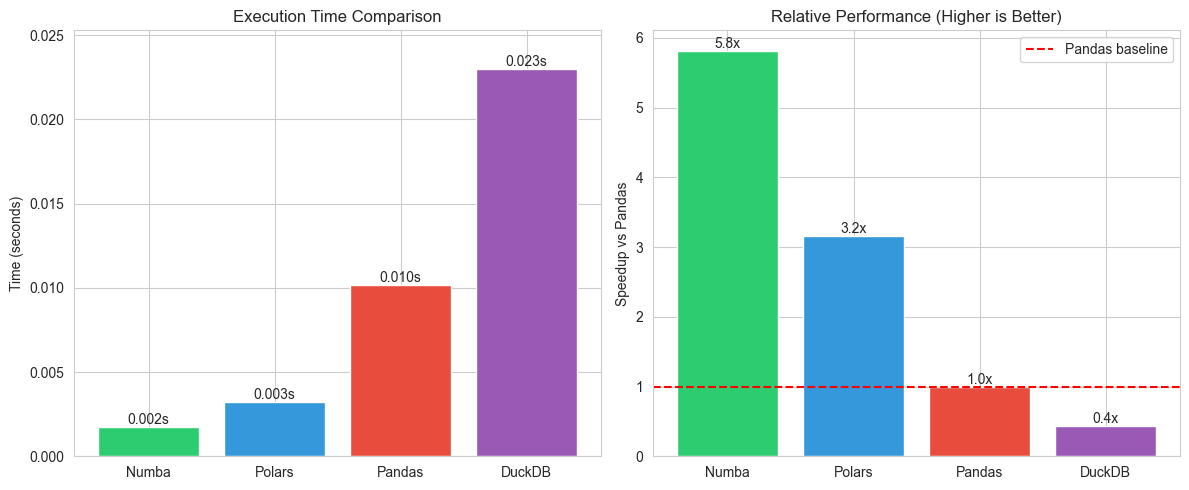

In [9]:
# Performance comparison
performance_data = {
    'Method': ['Polars', 'DuckDB', 'Pandas', 'Numba'],
    'Time (seconds)': [polars_time, duckdb_time, pandas_time, numba_time],
    'Relative Speed': [
        pandas_time / polars_time,
        pandas_time / duckdb_time,
        1.0,
        pandas_time / numba_time
    ]
}

perf_df = pd.DataFrame(performance_data)
perf_df = perf_df.sort_values('Time (seconds)')

print("Performance Comparison:")
print(perf_df.to_string(index=False))
print(f"\nFastest method: {perf_df.iloc[0]['Method']}")
print(f"Speedup over Pandas: {perf_df.iloc[0]['Relative Speed']:.1f}x")

# Visualize performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart of execution times
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']
ax1.bar(perf_df['Method'], perf_df['Time (seconds)'], color=colors)
ax1.set_ylabel('Time (seconds)')
ax1.set_title('Execution Time Comparison')
ax1.set_ylim(0, max(perf_df['Time (seconds)']) * 1.1)

# Add value labels on bars
for i, (method, time) in enumerate(zip(perf_df['Method'], perf_df['Time (seconds)'])):
    ax1.text(i, time, f'{time:.3f}s', ha='center', va='bottom')

# Speedup comparison
ax2.bar(perf_df['Method'], perf_df['Relative Speed'], color=colors)
ax2.set_ylabel('Speedup vs Pandas')
ax2.set_title('Relative Performance (Higher is Better)')
ax2.axhline(y=1, color='red', linestyle='--', label='Pandas baseline')
ax2.legend()

# Add value labels on bars
for i, (method, speed) in enumerate(zip(perf_df['Method'], perf_df['Relative Speed'])):
    ax2.text(i, speed, f'{speed:.1f}x', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 8. Visualize Dollar Bars

Let's visualize the created dollar bars as a candlestick chart:

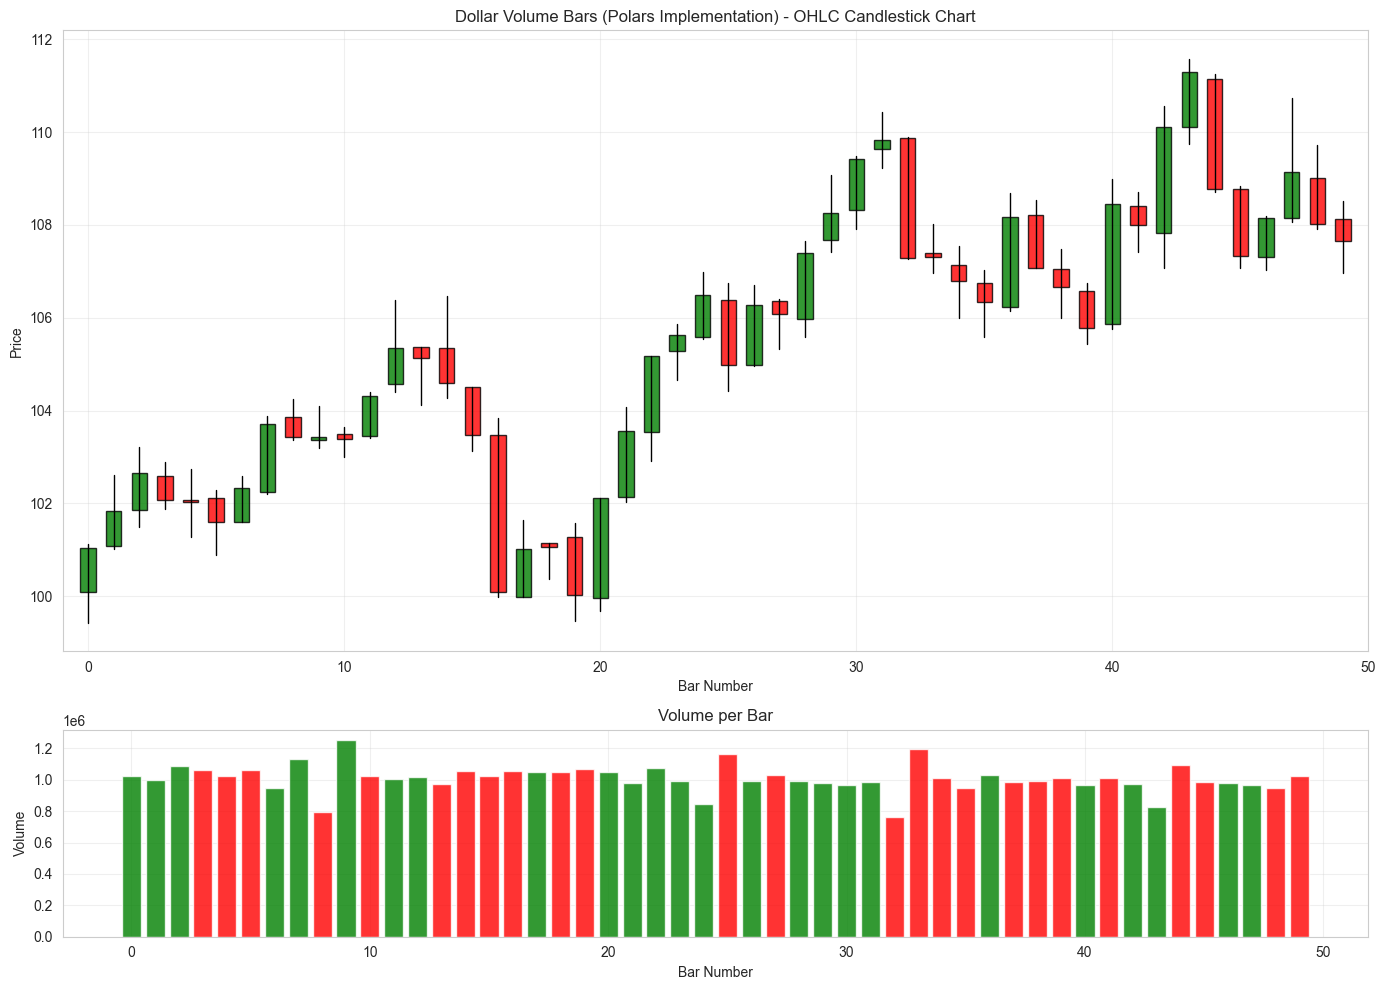

In [10]:
from matplotlib.patches import Rectangle

def plot_candlestick(bars_df: pd.DataFrame, title: str = "Dollar Bars", max_bars: int = 50):
    """
    Plot candlestick chart for dollar bars.
    """
    bars_to_plot = bars_df.head(max_bars)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})
    
    # Candlestick chart
    for idx, row in bars_to_plot.iterrows():
        color = 'green' if row['close'] > row['open'] else 'red'
        
        # Draw the high-low line
        ax1.plot([idx, idx], [row['low'], row['high']], color='black', linewidth=1)
        
        # Draw the open-close rectangle
        height = abs(row['close'] - row['open'])
        bottom = min(row['open'], row['close'])
        rect = Rectangle((idx - 0.3, bottom), 0.6, height, 
                        facecolor=color, alpha=0.8, edgecolor='black')
        ax1.add_patch(rect)
    
    ax1.set_xlim(-1, len(bars_to_plot))
    ax1.set_xlabel('Bar Number')
    ax1.set_ylabel('Price')
    ax1.set_title(f'{title} - OHLC Candlestick Chart')
    ax1.grid(True, alpha=0.3)
    
    # Volume bars
    colors = ['green' if c > o else 'red' 
              for c, o in zip(bars_to_plot['close'], bars_to_plot['open'])]
    ax2.bar(range(len(bars_to_plot)), bars_to_plot['volume'], color=colors, alpha=0.8)
    ax2.set_xlabel('Bar Number')
    ax2.set_ylabel('Volume')
    ax2.set_title('Volume per Bar')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Convert Polars result to pandas for visualization
dollar_bars_viz = dollar_bars_pl.to_pandas()
plot_candlestick(dollar_bars_viz, "Dollar Volume Bars (Polars Implementation)")

## 9. Statistical Properties of Dollar Bars

One advantage of dollar bars is their statistical properties:

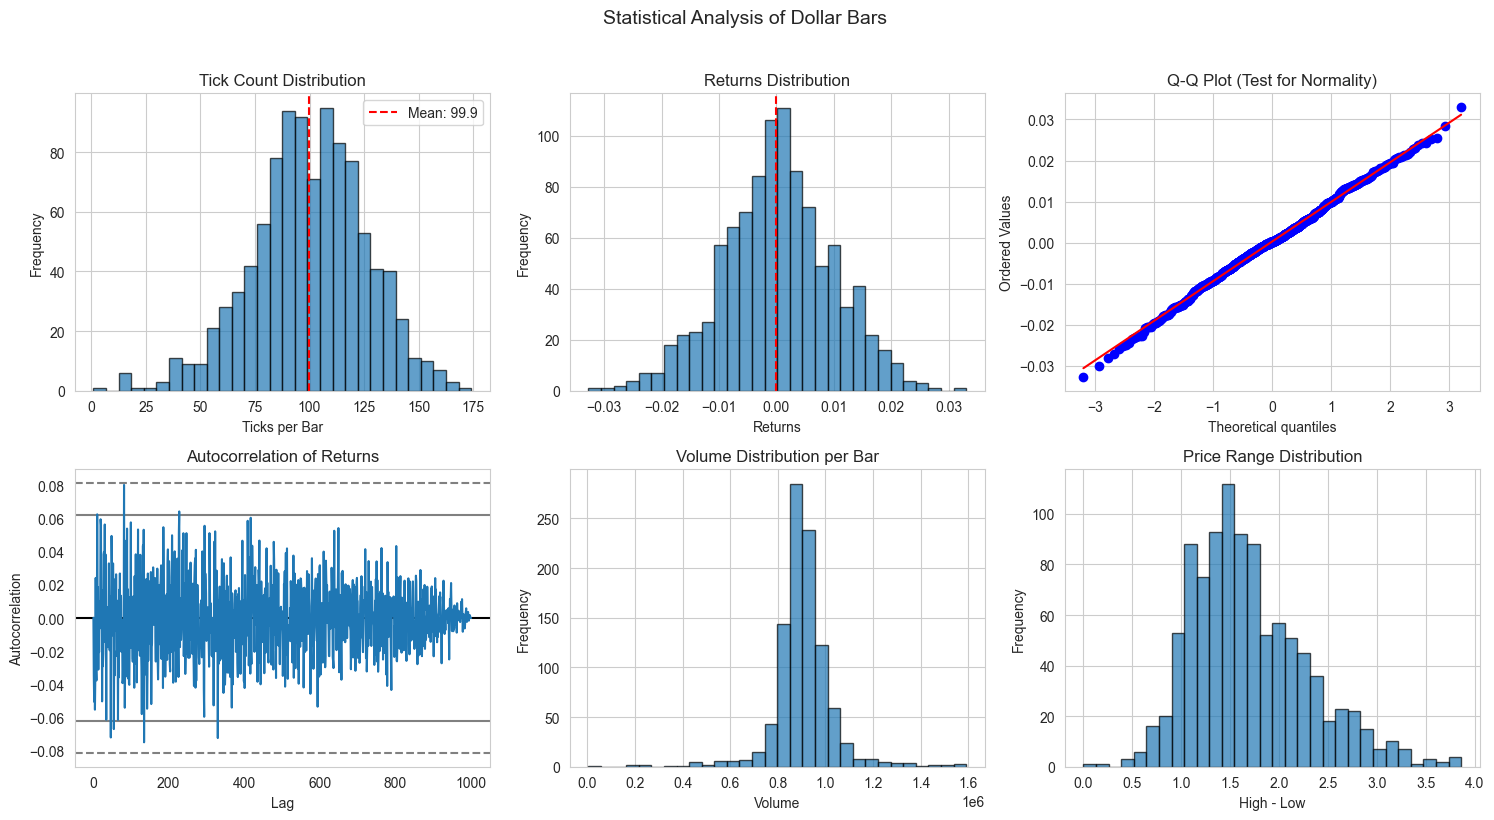


Dollar Bars Statistics:
Number of bars: 1001
Average ticks per bar: 99.9 ± 26.1
Average volume per bar: 905986 ± 131075

Returns Statistics:
  Mean return: 0.0298%
  Std deviation: 0.9638%
  Skewness: -0.058
  Kurtosis: 0.138

Jarque-Bera Test for Normality:
  Statistic: 1.289
  P-value: 0.525
  Returns are normally distributed (α=0.05)


In [11]:
def analyze_bar_statistics(bars_df: pd.DataFrame, bar_type: str = "Dollar"):
    """
    Analyze statistical properties of the bars.
    """
    # Calculate returns
    bars_df['returns'] = bars_df['close'].pct_change()
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    # 1. Distribution of tick counts per bar
    axes[0, 0].hist(bars_df['tick_count'], bins=30, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Tick Count Distribution')
    axes[0, 0].set_xlabel('Ticks per Bar')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].axvline(bars_df['tick_count'].mean(), color='red', 
                       linestyle='--', label=f'Mean: {bars_df["tick_count"].mean():.1f}')
    axes[0, 0].legend()
    
    # 2. Distribution of returns
    axes[0, 1].hist(bars_df['returns'].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0, 1].set_title('Returns Distribution')
    axes[0, 1].set_xlabel('Returns')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].axvline(0, color='red', linestyle='--')
    
    # 3. QQ plot for normality test
    from scipy import stats
    stats.probplot(bars_df['returns'].dropna(), dist="norm", plot=axes[0, 2])
    axes[0, 2].set_title('Q-Q Plot (Test for Normality)')
    
    # 4. Autocorrelation of returns
    from pandas.plotting import autocorrelation_plot
    autocorrelation_plot(bars_df['returns'].dropna(), ax=axes[1, 0])
    axes[1, 0].set_title('Autocorrelation of Returns')
    axes[1, 0].set_ylabel('Autocorrelation')
    
    # 5. Volume per bar
    axes[1, 1].hist(bars_df['volume'], bins=30, edgecolor='black', alpha=0.7)
    axes[1, 1].set_title('Volume Distribution per Bar')
    axes[1, 1].set_xlabel('Volume')
    axes[1, 1].set_ylabel('Frequency')
    
    # 6. Price range (high - low) per bar
    price_range = bars_df['high'] - bars_df['low']
    axes[1, 2].hist(price_range, bins=30, edgecolor='black', alpha=0.7)
    axes[1, 2].set_title('Price Range Distribution')
    axes[1, 2].set_xlabel('High - Low')
    axes[1, 2].set_ylabel('Frequency')
    
    plt.suptitle(f'Statistical Analysis of {bar_type} Bars', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{bar_type} Bars Statistics:")
    print("="*50)
    print(f"Number of bars: {len(bars_df)}")
    print(f"Average ticks per bar: {bars_df['tick_count'].mean():.1f} ± {bars_df['tick_count'].std():.1f}")
    print(f"Average volume per bar: {bars_df['volume'].mean():.0f} ± {bars_df['volume'].std():.0f}")
    print(f"\nReturns Statistics:")
    print(f"  Mean return: {bars_df['returns'].mean():.4%}")
    print(f"  Std deviation: {bars_df['returns'].std():.4%}")
    print(f"  Skewness: {bars_df['returns'].skew():.3f}")
    print(f"  Kurtosis: {bars_df['returns'].kurtosis():.3f}")
    
    # Jarque-Bera test for normality
    jb_stat, jb_pvalue = stats.jarque_bera(bars_df['returns'].dropna())
    print(f"\nJarque-Bera Test for Normality:")
    print(f"  Statistic: {jb_stat:.3f}")
    print(f"  P-value: {jb_pvalue:.3f}")
    print(f"  Returns are {'normally distributed' if jb_pvalue > 0.05 else 'NOT normally distributed'} (α=0.05)")

analyze_bar_statistics(dollar_bars_viz)

## 10. Advanced Dollar Bar Features

Let's implement some advanced features for dollar bars:

Created 484 adaptive dollar bars

Threshold adaptation over time:


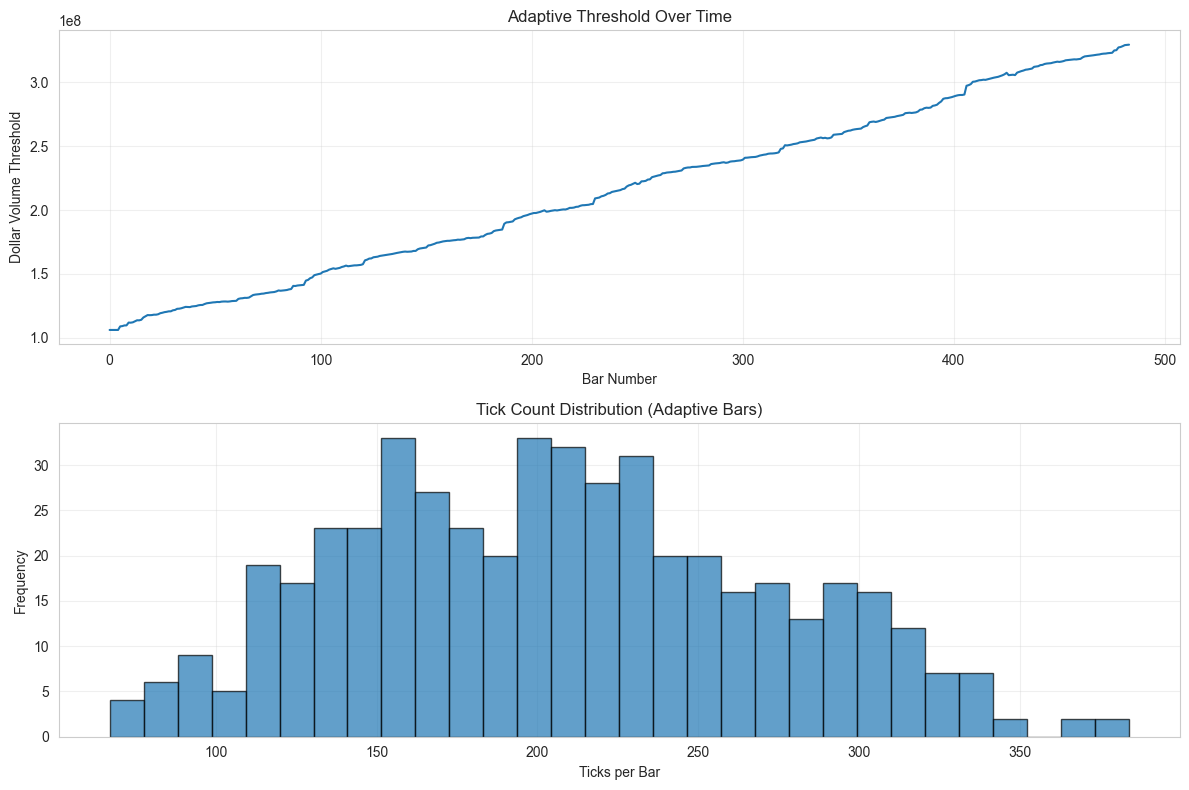

In [12]:
def create_adaptive_dollar_bars(df: pl.DataFrame, initial_threshold: float, 
                                lookback_bars: int = 20) -> pl.DataFrame:
    """
    Create dollar bars with adaptive thresholds based on recent activity.
    
    The threshold adjusts based on the exponential moving average of recent bar sizes.
    """
    bars = []
    current_threshold = initial_threshold
    recent_volumes = []
    
    # Convert to pandas for easier iteration (in production, use Polars lazy evaluation)
    df_pd = df.to_pandas()
    
    cum_dollar_volume = 0
    bar_start_idx = 0
    
    for i in range(len(df_pd)):
        dollar_volume = df_pd.iloc[i]['price'] * df_pd.iloc[i]['volume']
        cum_dollar_volume += dollar_volume
        
        if cum_dollar_volume >= current_threshold:
            # Create bar
            bar_data = df_pd.iloc[bar_start_idx:i+1]
            
            bar = {
                'timestamp': bar_data.iloc[0]['timestamp'],
                'open': bar_data.iloc[0]['price'],
                'high': bar_data['price'].max(),
                'low': bar_data['price'].min(),
                'close': bar_data.iloc[-1]['price'],
                'volume': bar_data['volume'].sum(),
                'dollar_volume': cum_dollar_volume,
                'tick_count': len(bar_data),
                'threshold_used': current_threshold
            }
            bars.append(bar)
            recent_volumes.append(cum_dollar_volume)
            
            # Update adaptive threshold
            if len(recent_volumes) > lookback_bars:
                recent_volumes.pop(0)
            
            if len(recent_volumes) >= 5:  # Need minimum bars for adaptation
                # Use exponential weighted average
                weights = np.exp(np.linspace(-1, 0, len(recent_volumes)))
                weights /= weights.sum()
                current_threshold = np.average(recent_volumes, weights=weights) * 1.0
            
            # Reset
            cum_dollar_volume = 0
            bar_start_idx = i + 1
    
    return pl.DataFrame(bars)

# Create adaptive dollar bars
adaptive_bars = create_adaptive_dollar_bars(tick_data_pl, dollar_threshold, lookback_bars=20)

print(f"Created {len(adaptive_bars)} adaptive dollar bars")
print(f"\nThreshold adaptation over time:")

# Plot threshold adaptation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(adaptive_bars['threshold_used'].to_pandas())
ax1.set_title('Adaptive Threshold Over Time')
ax1.set_xlabel('Bar Number')
ax1.set_ylabel('Dollar Volume Threshold')
ax1.grid(True, alpha=0.3)

ax2.hist(adaptive_bars['tick_count'].to_pandas(), bins=30, edgecolor='black', alpha=0.7)
ax2.set_title('Tick Count Distribution (Adaptive Bars)')
ax2.set_xlabel('Ticks per Bar')
ax2.set_ylabel('Frequency')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Real-world Example: Binance Integration

Example of how to integrate with real Binance data:

In [13]:
class BinanceDollarBarProcessor:
    """
    Process Binance tick data into dollar bars.
    """
    
    def __init__(self, symbol: str, dollar_threshold: float):
        self.symbol = symbol
        self.dollar_threshold = dollar_threshold
        self.bars = []
        self.current_ticks = []
        self.cum_dollar_volume = 0
        
    def process_tick(self, tick: dict) -> dict:
        """
        Process a single tick and return a bar if threshold is reached.
        
        Args:
            tick: Dict with keys 'price', 'volume', 'timestamp'
        
        Returns:
            Dollar bar dict if created, None otherwise
        """
        self.current_ticks.append(tick)
        dollar_volume = tick['price'] * tick['volume']
        self.cum_dollar_volume += dollar_volume
        
        if self.cum_dollar_volume >= self.dollar_threshold:
            # Create bar
            prices = [t['price'] for t in self.current_ticks]
            volumes = [t['volume'] for t in self.current_ticks]
            
            bar = {
                'symbol': self.symbol,
                'timestamp': self.current_ticks[0]['timestamp'],
                'open': prices[0],
                'high': max(prices),
                'low': min(prices),
                'close': prices[-1],
                'volume': sum(volumes),
                'dollar_volume': self.cum_dollar_volume,
                'tick_count': len(self.current_ticks),
                'vwap': self.cum_dollar_volume / sum(volumes)  # Volume-weighted average price
            }
            
            self.bars.append(bar)
            
            # Reset
            self.current_ticks = []
            self.cum_dollar_volume = 0
            
            return bar
        
        return None
    
    def get_bars_df(self) -> pd.DataFrame:
        """Return all bars as a DataFrame."""
        return pd.DataFrame(self.bars)

# Simulate real-time processing
print("Simulating real-time Binance tick processing...")
processor = BinanceDollarBarProcessor('BTCUSDT', dollar_threshold=1000000)

# Process ticks one by one (simulating real-time stream)
bars_created = 0
for i, row in tick_data.head(10000).iterrows():
    tick = {
        'price': row['price'],
        'volume': row['volume'],
        'timestamp': row['timestamp']
    }
    
    bar = processor.process_tick(tick)
    if bar:
        bars_created += 1
        if bars_created <= 3:  # Show first 3 bars
            print(f"\nBar {bars_created} created:")
            print(f"  OHLC: {bar['open']:.2f} / {bar['high']:.2f} / {bar['low']:.2f} / {bar['close']:.2f}")
            print(f"  Volume: {bar['volume']:.0f}")
            print(f"  Ticks: {bar['tick_count']}")
            print(f"  VWAP: {bar['vwap']:.2f}")

print(f"\nTotal bars created: {bars_created}")
print(f"Ticks processed: 10,000")
print(f"Average ticks per bar: {10000 / bars_created:.1f}")

Simulating real-time Binance tick processing...

Bar 1 created:
  OHLC: 100.08 / 100.08 / 100.08 / 100.08
  Volume: 66692
  Ticks: 1
  VWAP: 100.08

Bar 2 created:
  OHLC: 100.34 / 100.34 / 100.11 / 100.13
  Volume: 14259
  Ticks: 5
  VWAP: 100.20

Bar 3 created:
  OHLC: 100.17 / 100.23 / 100.17 / 100.23
  Volume: 10108
  Ticks: 2
  VWAP: 100.23

Total bars created: 3472
Ticks processed: 10,000
Average ticks per bar: 2.9


## 12. Storage with ArcticDB

Example of storing and retrieving dollar bars with ArcticDB:

In [14]:
# Note: ArcticDB requires installation and setup
# Uncomment the following to use ArcticDB

"""
from arcticdb import Arctic

# Initialize Arctic
arctic = Arctic("lmdb://dollar_bars_storage")

# Create or get library
lib = arctic.get_library('dollar_bars', create_if_missing=True)

# Store dollar bars
symbol = 'BTCUSDT'
lib.write(f'{symbol}_dollar_bars', dollar_bars_pl.to_pandas(), 
          metadata={'threshold': dollar_threshold, 'method': 'polars'})

print(f"Stored {len(dollar_bars_pl)} dollar bars for {symbol}")

# Read back dollar bars
retrieved_bars = lib.read(f'{symbol}_dollar_bars')
print(f"\nRetrieved {len(retrieved_bars.data)} bars")
print(f"Metadata: {retrieved_bars.metadata}")

# Query specific date range
start_date = datetime(2024, 1, 1)
end_date = datetime(2024, 1, 31)
date_range_bars = lib.read(f'{symbol}_dollar_bars', 
                           date_range=(start_date, end_date))
"""

print("ArcticDB storage example (commented out - requires ArcticDB installation)")
print("To use ArcticDB:")
print("1. Install: pip install arcticdb")
print("2. Uncomment the code above")
print("3. ArcticDB provides optimized storage for time-series financial data")

ArcticDB storage example (commented out - requires ArcticDB installation)
To use ArcticDB:
1. Install: pip install arcticdb
2. Uncomment the code above
3. ArcticDB provides optimized storage for time-series financial data


## Summary and Recommendations

Based on our analysis:

### Performance Rankings:
1. **Numba**: Fastest for pure computation
2. **Polars**: Best balance of speed and ease of use
3. **DuckDB**: Great for SQL users
4. **Pandas**: Slowest but most familiar

### Recommendations by Use Case:

- **Development/Research**: Use Polars or DuckDB
- **Production (< 100M ticks)**: Polars with ArcticDB storage
- **Production (> 100M ticks)**: Numba with chunked processing
- **Real-time streaming**: Custom Numba with message queue
- **Team familiar with SQL**: DuckDB

### Key Advantages of Dollar Bars:
1. More stable statistical properties than time bars
2. Better sampling for varying market activity
3. Reduced serial correlation in returns
4. More normally distributed returns

### Next Steps:
1. Test with your actual tick data
2. Optimize threshold selection
3. Implement in production pipeline
4. Monitor and adjust parameters